In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 500)

import requests
from bs4 import BeautifulSoup
import os
import s3fs
import ast
import json

In [2]:
os.environ['AWS_S3_ENDPOINT']
S3_ENDPOINT_URL = 'http://' + os.environ['AWS_S3_ENDPOINT']
fs = s3fs.S3FileSystem(client_kwargs = {'endpoint_url' :S3_ENDPOINT_URL })
fs.ls('mlepennec-ensae')
BUCKET = 'mlepennec-ensae'
FILE_KEY_S3 = '/movies_credits_budget.csv'
FILE_PATH_S3 = BUCKET+FILE_KEY_S3
with fs.open(FILE_PATH_S3, mode = "rb") as file_in : 
    df = pd.read_csv(file_in,sep=',', header=0)

/tmp/ipykernel_1354538/2833715930.py:9: DtypeWarning: Columns (12,22,23,36,37,38,39,40,41,42,43,44,45,46,47,48,49,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_in,sep=',', header=0)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42028 entries, 0 to 42027
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                8763 non-null   float64
 1   id                    42028 non-null  int64  
 2   imdb_id               42028 non-null  object 
 3   original_language     42028 non-null  object 
 4   original_title        42028 non-null  object 
 5   release_date          42028 non-null  object 
 6   revenue               42028 non-null  float64
 7   runtime               40726 non-null  float64
 8   title                 42028 non-null  object 
 9   vote_average          42028 non-null  float64
 10  vote_count            42028 non-null  float64
 11  indic_collec          42028 non-null  int64  
 12  nom_collec            4015 non-null   object 
 13  rang                  4015 non-null   float64
 14  max_rang              4015 non-null   float64
 15  vote_prec          

In [3]:
df=df[['budget_final', 'original_language', 'release_year', 'runtime', 'indic_collec', 'rang', 'genre1', 'prod1', 'pays1', 'acteur1', 'realisateur']]

In [4]:
df['rang'] = df['rang'].fillna(0)
# 1. Filtrer les lignes où 'budget' contient uniquement des chiffres
df_filtered = df[df['budget_final'].fillna('').str.isdigit()].copy()

# 2. Convertir la colonne 'budget' en type numérique (int)
df_filtered['budget_final'] = df_filtered['budget_final'].astype(int)


In [5]:
df_filtered

,budget_final,original_language,release_year,runtime,indic_collec,rang,genre1,prod1,pays1,acteur1,realisateur
0,70000000,en,2013,120.0,1,1.0,Action,Nu Image Films,United States of America,Gerard Butler,Antoine Fuqua
1,60000000,en,2016,99.0,1,2.0,Action,Millennium Films,Bulgaria,Gerard Butler,Creighton Rothenberger
6,4000000,en,1961,79.0,1,1.0,Adventure,Walt Disney Productions,United States of America,Rod Taylor,Walt Disney
8,54000000,en,1996,103.0,1,1.0,Comedy,Walt Disney Pictures,United Kingdom,Glenn Close,Michael Kamen
9,85000000,en,2000,100.0,1,2.0,Comedy,Walt Disney Pictures,United States of America,Glenn Close,David Newman
...,...,...,...,...,...,...,...,...,...,...,...
42007,1254040,fi,2017,90.0,0,0.0,Romance,Elokuvayhtiö Oy Aamu,Finland,Inka Haapamäki,Hannaleena Hauru
42011,60000000,en,2017,95.0,0,0.0,Action,Imagine Entertainment,South Africa,Idris Elba,Brian Grazer
42013,11000000,en,2017,111.0,0,0.0,Action,Thunder Road Pictures,United Kingdom,Jeremy Renner,Elizabeth A. Bell
42014,21000000,en,2017,95.0,0,0.0,Drama,Ingenious Media,United Kingdom,Halle Berry,Lorenzo di Bonaventura


In [6]:
df_filtered=df_filtered.dropna()

In [7]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7979 entries, 0 to 42024
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   budget_final       7979 non-null   int64  
 1   original_language  7979 non-null   object 
 2   release_year       7979 non-null   int64  
 3   runtime            7979 non-null   float64
 4   indic_collec       7979 non-null   int64  
 5   rang               7979 non-null   float64
 6   genre1             7979 non-null   object 
 7   prod1              7979 non-null   object 
 8   pays1              7979 non-null   object 
 9   acteur1            7979 non-null   object 
 10  realisateur        7979 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 748.0+ KB


In [14]:
import numpy as np # Pour des calculs mathématiques
import pandas as pd # Pour la manipulation de tableaux de données
import matplotlib.pyplot as plt # Pour les graphiques

from scipy.cluster.hierarchy import dendrogram,fcluster # Pour le dendrogramme
from scipy.spatial.distance import minkowski # Pour la distance de Minkowski
from sklearn.preprocessing import StandardScaler # Pour la normalisation des données
from sklearn.cluster import AgglomerativeClustering # Pour la CAH
from sklearn.cluster import KMeans # Pour les K-means

import plotly.express as px # Pour la cartographie
import gower

In [11]:
import pandas as pd
import gower
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


# 1. Calculer la distance de Gower
gower_dist = gower.gower_matrix(df_filtered)

# 2. Appliquer le clustering hiérarchique
Z = linkage(gower_dist, method='average')  # Attention : ward ne marche pas avec une matrice de distances directement !


/tmp/ipykernel_1354538/1463360564.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(gower_dist, method='average')  # Attention : ward ne marche pas avec une matrice de distances directement !


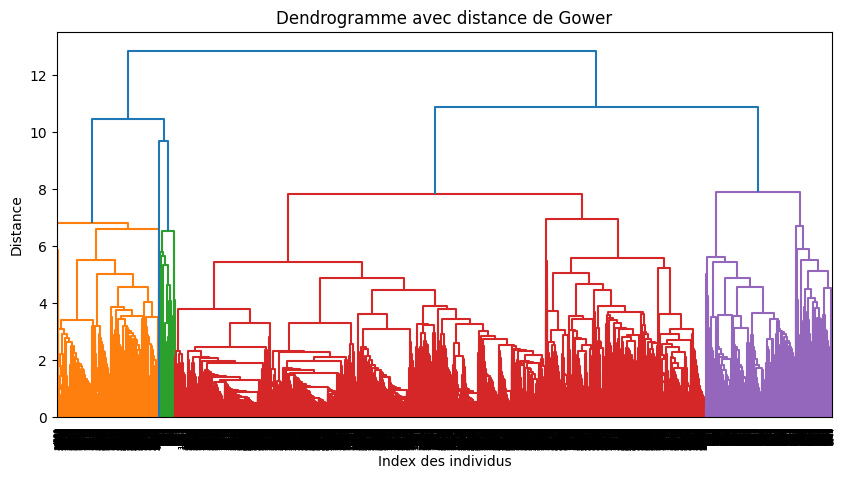

In [12]:
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df_filtered.index.tolist())
plt.title("Dendrogramme avec distance de Gower")
plt.xlabel("Index des individus")
plt.ylabel("Distance")
plt.show()


In [54]:
#clusters = fcluster(Z, t=2, criterion='maxclust')

# Option 2 : couper selon une distance seuil (par exemple 0.5)
clusters = fcluster(Z, t=10, criterion='distance')

# Ajouter la colonne des clusters dans le DataFrame
df_filtered['cluster'] = clusters

print(df_filtered)

       budget_final original_language  release_year  runtime  indic_collec  \
0          70000000                en          2013    120.0             1   
1          60000000                en          2016     99.0             1   
6           4000000                en          1961     79.0             1   
8          54000000                en          1996    103.0             1   
9          85000000                en          2000    100.0             1   
...             ...               ...           ...      ...           ...   
42007       1254040                fi          2017     90.0             0   
42011      60000000                en          2017     95.0             0   
42013      11000000                en          2017    111.0             0   
42014      21000000                en          2017     95.0             0   
42024       4696772                en          2017    130.0             0   

       rang     genre1                    prod1                

/tmp/ipykernel_1354538/2517554875.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['cluster'] = clusters


In [55]:
df_filtered['cluster']

0        4
1        4
6        4
8        4
9        4
        ..
42007    1
42011    3
42013    3
42014    3
42024    3
Name: cluster, Length: 7979, dtype: int32

In [28]:
pd.set_option('display.max_rows', 500)

In [56]:
df_filtered[df_filtered['cluster'] == 2]

,budget_final,original_language,release_year,runtime,indic_collec,rang,genre1,prod1,pays1,acteur1,realisateur,cluster
18,20000000,ja,2008,142.0,1,1.0,Science Fiction,Cine Bazar,Japan,Toshiaki Karasawa,Seiji Okuda,2
102,1380000,fi,2006,78.0,1,3.0,Crime,Sputnik Oy,Finland,Janne Hyytiäinen,Aki Kaurismäki,2
219,10000000,ja,2004,101.0,1,1.0,Animation,Toho Company,Japan,Ai Kobayashi,Haruyo Kanesaku,2
225,15000000,cn,1986,88.0,1,1.0,Adventure,Jadran Film,Hong Kong,Jackie Chan,Jackie Chan,2
227,48000000,cn,2012,120.0,1,3.0,Action,Emperor Motion Pictures,Hong Kong,Jackie Chan,Jackie Chan,2
228,25000000,sv,2007,139.0,1,1.0,Action,Danmarks Radio (DR),Sweden,Joakim Nätterqvist,Eric Kress,2
245,30000000,fr,2014,85.0,1,9.0,Animation,Canal Plus,France,Roger Carel,Philippe Rombi,2
248,97250400,fr,2008,116.0,1,3.0,Fantasy,Constantin Film,Belgium,Clovis Cornillac,Thierry Arbogast,2
249,61000000,fr,2012,110.0,1,4.0,Family,France 2 Cinéma,France,Gérard Depardieu,Olivier Delbosc,2
295,40000000,te,2015,159.0,1,1.0,Action,Arka Media Works,India,Prabhas,S.S. Rajamouli,2
